# DirectNet — detecția nesupravegheată a anomaliilor hiperspectrale

Acest notebook reproduce fluxul proiectului DirectNet **fără ground truth**. Se descarcă automat una dintre două scene hiperspectrale EnMAP L2A, se extrage un crop, apoi se rulează:

- pseudocolor PCA;
- baseline-ul statistic GRX;
- DirectNet cu mascarea blocului central;
- variația hiperparametrilor `Win` și `Wout`;
- alegerea configurației finale fără etichete;
- analiza pragurilor bazate pe percentile;
- salvarea hărților și a celor mai puternici candidați de anomalie.

Modelul nu identifică semantic obiectele. El oferă un scor mare pixelilor care nu pot fi reconstruiți bine din contextul local.
> Notă: notebook-ul folosește linkurile oficiale actuale EnMAP, care livrează arhive `.zip`.


## 1. Alegerea imaginii

Modifică doar `DATASET_VARIANT`:

- `1` — **Tyrol, Austria**, EnMAP L2A;
- `2` — **Nevada, SUA**, EnMAP L2A.

Notebook-ul descarcă numai varianta selectată. Produsele sunt scene exemplu publicate de EnMAP și conțin reflectanță de suprafață. Arhivele pot fi mari, deci descărcarea poate dura.

In [1]:
# Rulează această celulă o singură dată într-un mediu nou.
%pip install -q numpy pandas matplotlib scipy scikit-learn torch rasterio requests

In [2]:
from __future__ import annotations

import copy
import gc
import random
import shutil
import tarfile
import zipfile
import time
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import Image, display
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, RandomSampler, Subset

# -----------------------------------------------------------------------------
# SELECȚIA SURSEI: schimbă numai 1 sau 2.
# -----------------------------------------------------------------------------
DATASET_VARIANT = 2

DATASET_OPTIONS = {
    1: {
        "name": "EnMAP Tyrol, Austria — L2A",
        "slug": "enmap_tyrol_l2a",
        "url": "https://www.enmap.org/data/example_data/Tyrol_Austria_L2A.zip",
        "archive": "Tyrol_Austria_L2A.zip",
    },
    2: {
        "name": "EnMAP Nevada, SUA — L2A",
        "slug": "enmap_nevada_l2a",
        "url": "https://www.enmap.org/data/example_data/Nevada_USA_L2A.zip",
        "archive": "Nevada_USA_L2A.zip",
    },
}

# Crop-ul este folosit deoarece scenele satelitare complete sunt foarte mari.
SATELLITE_CROP_SIZE = 256
ROI_ROW = None       # None = crop centrat
ROI_COL = None       # None = crop centrat

# Pentru o verificare mai rapidă poți pune True.
QUICK_MODE = False
LOADER_ONLY = False

SEED = 42
DEFAULT_THRESHOLD_PERCENTILE = 99.5
BATCH_SIZE = 100
INFERENCE_BATCH_SIZE = 256
LEARNING_RATE = 1e-4
NUM_WORKERS = 0
HIDDEN_CHANNELS = 64
WIN_VALUES = [1, 3, 5, 7, 9]
WOUT_VALUES = [15, 19, 23]
REFERENCE_WOUT = 19

if DATASET_VARIANT not in DATASET_OPTIONS:
    raise ValueError("DATASET_VARIANT trebuie să fie 1 sau 2.")

if QUICK_MODE:
    MAX_EPOCHS = 35
    TRAIN_SAMPLES_PER_EPOCH = 5000
    VALIDATION_SAMPLES = 1800
    PATIENCE = 7
else:
    MAX_EPOCHS = 80
    TRAIN_SAMPLES_PER_EPOCH = 10000
    VALIDATION_SAMPLES = 2500
    PATIENCE = 12

PROJECT_DIR = Path.cwd()
DOWNLOAD_DIR = PROJECT_DIR / "hsi_downloads"
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

ARGS = SimpleNamespace(
    crop_size=SATELLITE_CROP_SIZE,
    row=ROI_ROW,
    col=ROI_COL,
    loader_only=LOADER_ONLY,
)


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()
torch.backends.cudnn.benchmark = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Sursă selectată:", DATASET_OPTIONS[DATASET_VARIANT]["name"])
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("Quick mode:", QUICK_MODE)

Sursă selectată: EnMAP Nevada, SUA — L2A
PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4
Quick mode: False


## 2. Descărcarea și extragerea produsului EnMAP

Fișierul este descărcat o singură dată. La rulările următoare se reutilizează arhiva și folderul deja extras. Linkurile oficiale actuale livrează arhive `.zip`. Funcția de extragere acceptă atât ZIP, cât și TAR și verifică să nu se scrie în afara folderului proiectului.

In [3]:
def download_file(url: str, destination: Path, chunk_size: int = 1024 * 1024) -> Path:
    """Descarcă sigur fișierul și îl reutilizează dacă există deja."""
    if destination.exists() and destination.stat().st_size > 0:
        print("Arhiva există deja:", destination)
        return destination

    temporary_path = destination.with_suffix(destination.suffix + ".part")
    temporary_path.unlink(missing_ok=True)

    print("Descarc:", url)
    headers = {"User-Agent": "Mozilla/5.0 DirectNet-EnMAP-Notebook/1.0"}

    try:
        with requests.get(
            url,
            stream=True,
            timeout=(30, 600),
            headers=headers,
            allow_redirects=True,
        ) as response:
            response.raise_for_status()

            content_type = response.headers.get("content-type", "").lower()
            if "text/html" in content_type:
                raise RuntimeError(
                    "Serverul a întors o pagină HTML în locul arhivei. "
                    "Verifică linkul oficial EnMAP."
                )

            total = int(response.headers.get("content-length", 0))
            downloaded = 0

            with temporary_path.open("wb") as file:
                for chunk in response.iter_content(chunk_size=chunk_size):
                    if not chunk:
                        continue
                    file.write(chunk)
                    downloaded += len(chunk)
                    if total:
                        print(
                            f"\r{downloaded / 1024**2:.1f} / "
                            f"{total / 1024**2:.1f} MB",
                            end="",
                        )

        print()
        temporary_path.replace(destination)
        return destination

    except Exception:
        temporary_path.unlink(missing_ok=True)
        raise


def _validate_member_path(destination: Path, member_name: str) -> None:
    root = destination.resolve()
    target = (destination / member_name).resolve()
    if target != root and root not in target.parents:
        raise RuntimeError(f"Cale nesigură în arhivă: {member_name}")


def safe_extract_archive(archive_path: Path, destination: Path) -> Path:
    """Extrage în siguranță o arhivă ZIP sau TAR/TAR.GZ."""
    marker = destination / ".extracted_ok"
    if marker.exists() and any(destination.rglob("*.TIF")):
        print("Arhiva este deja extrasă:", destination)
        return destination

    if destination.exists():
        shutil.rmtree(destination)
    destination.mkdir(parents=True, exist_ok=True)

    suffixes = "".join(archive_path.suffixes).lower()

    if archive_path.suffix.lower() == ".zip":
        with zipfile.ZipFile(archive_path, "r") as archive:
            for member in archive.infolist():
                _validate_member_path(destination, member.filename)
            archive.extractall(destination)

    elif suffixes.endswith((".tar.gz", ".tgz", ".tar")):
        with tarfile.open(archive_path, "r:*") as archive:
            for member in archive.getmembers():
                _validate_member_path(destination, member.name)
            archive.extractall(destination)

    else:
        raise ValueError(f"Format de arhivă nesuportat: {archive_path.name}")

    marker.write_text("ok", encoding="utf-8")
    print("Extras în:", destination)
    return destination


selected_source = DATASET_OPTIONS[DATASET_VARIANT]
archive_path = DOWNLOAD_DIR / selected_source["archive"]
extract_dir = DOWNLOAD_DIR / selected_source["slug"]

download_file(selected_source["url"], archive_path)
safe_extract_archive(archive_path, extract_dir)


Descarc: https://www.enmap.org/data/example_data/Nevada_USA_L2A.zip
350.3 / 350.3 MB
Extras în: /content/hsi_downloads/enmap_nevada_l2a


PosixPath('/content/hsi_downloads/enmap_nevada_l2a')

## 3. Încărcarea cubului hiperspectral

Fișierele GeoTIFF spectrale VNIR și SWIR sunt căutate automat în arhivă. Datele sunt transformate din forma folosită de rastere, `benzi × înălțime × lățime`, în forma utilizată de model, `înălțime × lățime × benzi`.

Benzile cu prea multe valori invalide sau fără variație sunt eliminate. Restul valorilor invalide sunt înlocuite cu mediana benzii.

In [4]:
def compute_roi(height, width, crop_size, row=None, col=None):
    if crop_size in (None, 0):
        return 0, height, 0, width
    if crop_size < 1:
        raise ValueError("crop_size trebuie să fie pozitiv sau 0 pentru scena completă.")

    crop_h = min(int(crop_size), int(height))
    crop_w = min(int(crop_size), int(width))
    start_row = (height - crop_h) // 2 if row is None else int(row)
    start_col = (width - crop_w) // 2 if col is None else int(col)

    if start_row < 0 or start_col < 0:
        raise ValueError("ROI_ROW și ROI_COL nu pot fi negative.")
    if start_row + crop_h > height or start_col + crop_w > width:
        raise ValueError(
            f"Crop-ul ({start_row}:{start_row + crop_h}, "
            f"{start_col}:{start_col + crop_w}) depășește scena {height}x{width}."
        )
    return start_row, start_row + crop_h, start_col, start_col + crop_w

def find_enmap_files(path):
    from pathlib import Path
    import rasterio

    path = Path(path)

    if path.is_file():
        return [path]

    extensii_acceptate = {
        ".tif",
        ".tiff",
        ".bsq",
        ".bil",
        ".bip",
        ".jp2",
        ".jpeg2000",
    }

    # Căutăm direct cubul spectral, nu quicklook-urile și măștile.
    candidates = [
        p for p in path.rglob("*")
        if p.is_file()
        and p.suffix.lower() in extensii_acceptate
        and "SPECTRAL_IMAGE" in p.name.upper()
    ]

    # Variantă de rezervă dacă numele nu conține SPECTRAL_IMAGE.
    if not candidates:
        candidates = [
            p for p in path.rglob("*")
            if p.is_file()
            and p.suffix.lower() in extensii_acceptate
            and not any(token in p.name.upper() for token in (
                "QUALITY",
                "QL_",
                "MASK",
                "CLOUD",
                "CIRRUS",
                "SNOW",
                "PIXELMASK",
                "TESTFLAGS",
                "THUMBNAIL",
            ))
        ]

    readable = []

    for file_path in candidates:
        try:
            with rasterio.open(file_path) as src:
                print(
                    f"Fișier găsit: {file_path.name} | "
                    f"benzi={src.count}"
                )

                if src.count > 10:
                    readable.append((file_path, src.count))
        except Exception:
            continue

    if not readable:
        raise RuntimeError(
            "Nu am găsit cubul spectral EnMAP. "
            "Verifică dacă arhiva a fost extrasă complet."
        )

    # Alegem fișierul cu cele mai multe benzi.
    spectral_file = max(readable, key=lambda item: item[1])[0]

    print("Cub spectral selectat:", spectral_file)

    return [spectral_file]

    def is_bad_name(file_path):
        upper = file_path.name.upper()
        return any(token in upper for token in (
            "QUALITY", "QL_", "MASK", "CLOUD", "CIRRUS", "SNOW", "QUICKLOOK",
            "PIXELMASK", "TESTFLAGS", "CLASSIFICATION"
        ))

    spectral_named = [p for p in candidates if "SPECTRAL_IMAGE" in p.name.upper() and not is_bad_name(p)]
    pool = spectral_named if spectral_named else [p for p in candidates if not is_bad_name(p)]

    vnir_files = [p for p in pool if "VNIR" in p.name.upper()]
    swir_files = [p for p in pool if "SWIR" in p.name.upper()]

    def band_count(file_path):
        with rasterio.open(file_path) as src:
            return src.count

    if vnir_files and swir_files:
        return [max(vnir_files, key=band_count), max(swir_files, key=band_count)]

    multiband = [p for p in pool if band_count(p) > 10]
    if not multiband:
        raise RuntimeError("Nu am identificat un GeoTIFF spectral EnMAP cu mai mult de 10 benzi.")
    return [max(multiband, key=band_count)]

def load_enmap(path):
    try:
        import rasterio
        from rasterio.windows import Window
    except ImportError as exc:
        raise ImportError("Pentru EnMAP instalează rasterio: pip install rasterio") from exc

    files = find_enmap_files(path)
    shapes = []
    descriptions = []
    for file_path in files:
        with rasterio.open(file_path) as src:
            shapes.append((src.height, src.width))
            descriptions.append(f"{file_path.name}: ({src.height}, {src.width}, {src.count})")

    height = min(shape[0] for shape in shapes)
    width = min(shape[1] for shape in shapes)
    crop_size = SATELLITE_CROP_SIZE if ARGS.crop_size is None else ARGS.crop_size
    row = ROI_ROW if ARGS.row is None else ARGS.row
    col = ROI_COL if ARGS.col is None else ARGS.col
    r0, r1, c0, c1 = compute_roi(height, width, crop_size, row, col)
    window = Window(c0, r0, c1 - c0, r1 - r0)

    cubes = []
    for file_path in files:
        with rasterio.open(file_path) as src:
            data = src.read(window=window, out_dtype="float32")
            if src.nodata is not None:
                data[np.isclose(data, float(src.nodata))] = np.nan

            scales = np.asarray(src.scales, dtype=np.float32)
            offsets = np.asarray(src.offsets, dtype=np.float32)
            if scales.size == src.count and offsets.size == src.count:
                data = data * scales[:, None, None] + offsets[:, None, None]
            cubes.append(np.moveaxis(data, 0, -1))

    if len(cubes) == 2 and cubes[0].shape[:2] != cubes[1].shape[:2]:
        raise ValueError(f"GeoTIFF-urile EnMAP nu se aliniază: {cubes[0].shape} vs {cubes[1].shape}.")
    cube = np.concatenate(cubes, axis=2) if len(cubes) > 1 else cubes[0]
    metadata = {
        "cube_key": " + ".join(file_path.name for file_path in files),
        "original_shape": " | ".join(descriptions),
        "orientation": "GeoTIFF BHW -> HWB",
        "roi": f"rows={r0}:{r1}, cols={c0}:{c1}",
        "source_files": " | ".join(str(file_path) for file_path in files),
    }
    return cube, metadata

def sanitize_hsi(cube):
    cube = np.asarray(cube, dtype=np.float32)
    if cube.ndim != 3:
        raise ValueError(f"HSI trebuie să fie 3D, nu {cube.shape}.")
    if min(cube.shape[:2]) < max(WOUT_VALUES):
        raise ValueError(
            f"Dimensiunea spațială {cube.shape[:2]} este prea mică pentru Wout={max(WOUT_VALUES)}."
        )

    flat = cube.reshape(-1, cube.shape[2])
    finite_fraction = np.isfinite(flat).mean(axis=0)
    keep = finite_fraction >= 0.50
    if not np.any(keep):
        raise RuntimeError("Nicio bandă nu are suficiente valori finite.")
    flat = flat[:, keep]

    medians = np.nanmedian(flat, axis=0)
    medians = np.where(np.isfinite(medians), medians, 0.0)
    invalid_rows, invalid_cols = np.where(~np.isfinite(flat))
    if invalid_rows.size:
        flat[invalid_rows, invalid_cols] = medians[invalid_cols]

    band_std = flat.std(axis=0)
    varying = band_std > 1e-8
    if not np.any(varying):
        raise RuntimeError("Toate benzile valide au variație nulă.")
    flat = flat[:, varying]
    cleaned = flat.reshape(cube.shape[0], cube.shape[1], -1).astype(np.float32)
    info = {
        "input_bands": int(cube.shape[2]),
        "bands_after_finite_filter": int(keep.sum()),
        "final_bands": int(varying.sum()),
    }
    return cleaned, info

In [5]:
DATASET_NAME = selected_source["slug"]
DATA_PATH = extract_dir

hsi_raw, source_metadata = load_enmap(DATA_PATH)
hsi, cleaning_info = sanitize_hsi(hsi_raw)
H, W, B = hsi.shape

pixels = hsi.reshape(-1, B)
band_mean = pixels.mean(axis=0, keepdims=True)
band_std = np.maximum(pixels.std(axis=0, keepdims=True), 1e-8)
pixels_z = (pixels - band_mean) / band_std
hsi_z = pixels_z.reshape(H, W, B).astype(np.float32)

SCRIPT_DIR = PROJECT_DIR
OUTPUT_DIR = SCRIPT_DIR / f"directnet_experiments_{DATASET_NAME}"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

cube_key = source_metadata["cube_key"]
orientation_info = source_metadata["orientation"]
source_original_shape = source_metadata["original_shape"]

print("\nSursa:", selected_source["name"])
print("Fișiere spectrale:", source_metadata["source_files"])
print("Formă originală:", source_original_shape)
print("Orientare:", orientation_info)
print("ROI:", source_metadata["roi"])
print("HSI final:", hsi_z.shape)
print("Benzi:", cleaning_info)
print("Ground truth: NU este folosit")

Fișier găsit: ENMAP01-____L2A-DT0000025905_20230707T192008Z_001_V010506_20260528T202617Z-SPECTRAL_IMAGE.BSQ | benzi=224
Cub spectral selectat: /content/hsi_downloads/enmap_nevada_l2a/ENMAP01-____L2A-DT0000025905_20230707T192008Z_001_V010506_20260528T202617Z/ENMAP01-____L2A-DT0000025905_20230707T192008Z_001_V010506_20260528T202617Z-SPECTRAL_IMAGE.BSQ

Sursa: EnMAP Nevada, SUA — L2A
Fișiere spectrale: /content/hsi_downloads/enmap_nevada_l2a/ENMAP01-____L2A-DT0000025905_20230707T192008Z_001_V010506_20260528T202617Z/ENMAP01-____L2A-DT0000025905_20230707T192008Z_001_V010506_20260528T202617Z-SPECTRAL_IMAGE.BSQ
Formă originală: ENMAP01-____L2A-DT0000025905_20230707T192008Z_001_V010506_20260528T202617Z-SPECTRAL_IMAGE.BSQ: (1197, 1286, 224)
Orientare: GeoTIFF BHW -> HWB
ROI: rows=470:726, cols=515:771
HSI final: (256, 256, 219)
Benzi: {'input_bands': 224, 'bands_after_finite_filter': 219, 'final_bands': 219}
Ground truth: NU este folosit


## 4. Pseudocolor PCA

O imagine hiperspectrală are zeci sau sute de benzi și nu poate fi afișată direct ca RGB. PCA comprimă informația spectrală în trei componente folosite doar pentru vizualizare. DirectNet continuă să folosească toate benzile valide.

In [6]:
# =============================================================================
# 3. PSEUDOCOLOR PCA
# =============================================================================

def percentile_stretch(image, low=2, high=98):
    output = np.zeros_like(image, dtype=np.float32)
    for channel in range(image.shape[-1]):
        band = image[..., channel]
        lo, hi = np.percentile(band, [low, high])
        if hi > lo:
            output[..., channel] = np.clip((band - lo) / (hi - lo), 0, 1)
    return output


pca = PCA(n_components=3, random_state=SEED)
pca_rgb = pca.fit_transform(pixels_z).reshape(H, W, 3)
pca_rgb = percentile_stretch(pca_rgb)

plt.figure(figsize=(7, 7))
plt.imshow(pca_rgb)
plt.title("Pseudocolor PCA")
plt.axis("off")
plt.savefig(FIGURE_DIR / "pseudocolor_pca.png", dpi=200, bbox_inches="tight")
plt.close()

if LOADER_ONLY:
    print("Loader verificat. PCA salvat în:", FIGURE_DIR / "pseudocolor_pca.png")

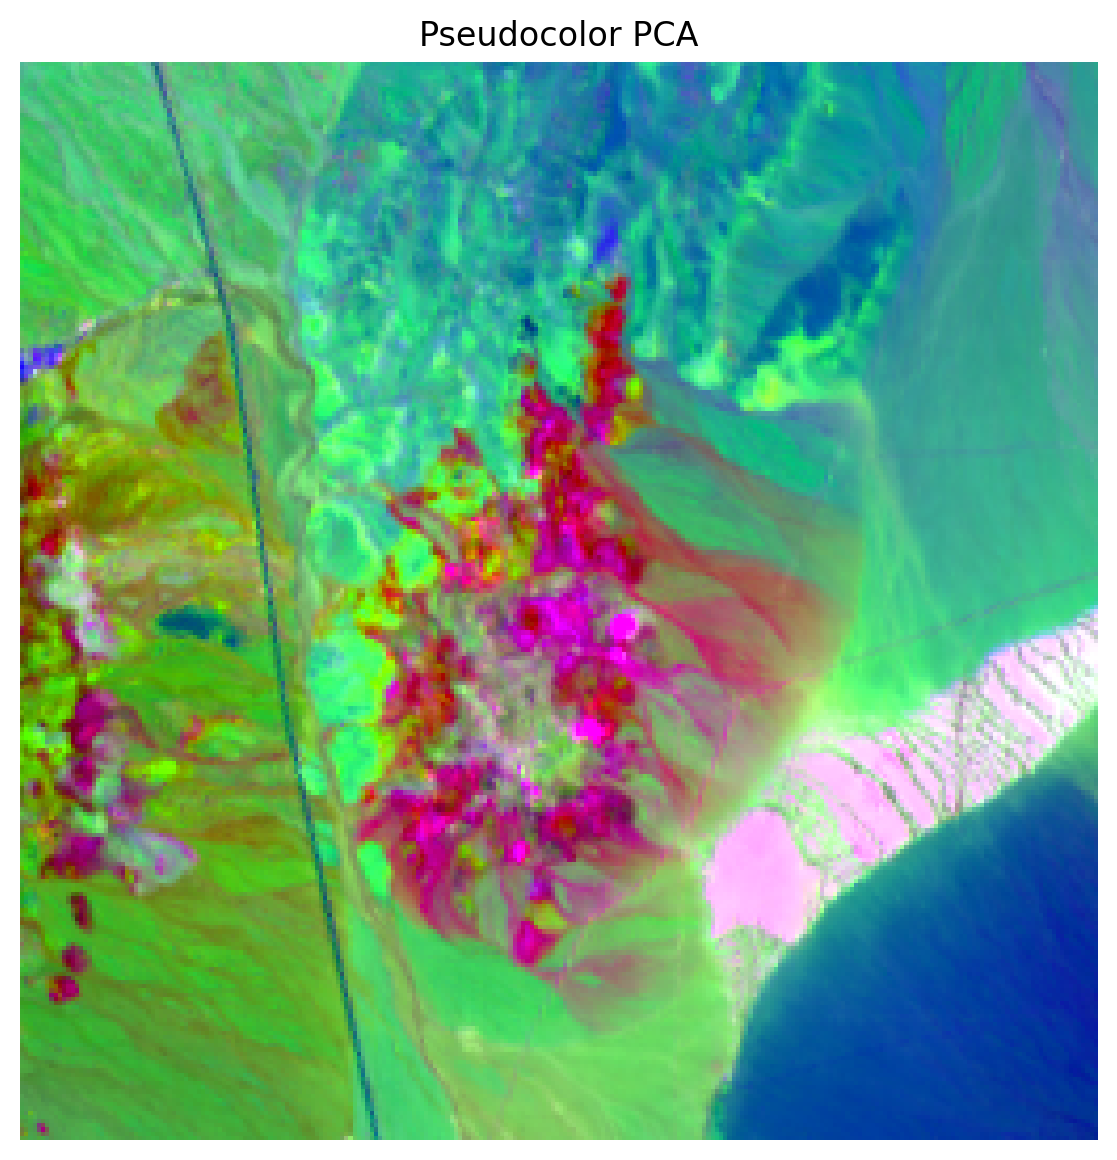

In [7]:
display(Image(filename=str(FIGURE_DIR / "pseudocolor_pca.png")))

## 5. Cum evaluăm fără ground truth

Fără etichete nu putem calcula ROC-AUC, Precision, Recall, FP sau FN. Pentru fiecare hartă de scoruri sunt calculate statistici nesupravegheate și un prag percentile-based.

La percentila `99.5`, aproximativ cei mai mari `0.5%` dintre pixeli sunt marcați drept **candidați de anomalie**, nu anomalii confirmate.

In [8]:
# =============================================================================
# 4. REZUMAT NESUPRAVEGHEAT AL SCORURILOR
# =============================================================================


def evaluate_scores(scores, percentile=DEFAULT_THRESHOLD_PERCENTILE):
    scores = np.asarray(scores, dtype=np.float64)
    q25, median, q75, p95, p99, p995 = np.percentile(
        scores, [25, 50, 75, 95, 99, 99.5]
    )
    iqr = max(q75 - q25, 1e-12)
    threshold = float(np.percentile(scores, percentile))
    prediction = (scores >= threshold).astype(np.uint8)
    return {
        "median_score": float(median),
        "p95_score": float(p95),
        "p99_score": float(p99),
        "p99_5_score": float(p995),
        "max_score": float(scores.max()),
        "tail_contrast": float((p995 - median) / iqr),
        "threshold": threshold,
        "threshold_method": f"percentile_{percentile}",
        "prediction": prediction,
        "flagged_pixels": int(prediction.sum()),
        "flagged_percent": float(100 * prediction.mean()),
    }

## 6. Baseline GRX

GRX măsoară cât de diferit este spectrul fiecărui pixel față de distribuția spectrală globală a scenei, folosind o distanță de tip Mahalanobis. Este rapid și oferă un punct de comparație pentru DirectNet.

In [9]:
# =============================================================================
# 5. BASELINE GRX
# =============================================================================


def global_rx_scores(pixels_standardized, regularization=1e-3):
    mean_vector = pixels_standardized.mean(axis=0, keepdims=True)
    centered = pixels_standardized - mean_vector
    covariance = np.atleast_2d(np.cov(centered, rowvar=False))
    scale = np.trace(covariance) / covariance.shape[0]
    covariance_regularized = (
        covariance
        + regularization * scale * np.eye(covariance.shape[0])
    )
    inverse_covariance = np.linalg.pinv(covariance_regularized)
    return np.einsum(
        "ij,jk,ik->i",
        centered,
        inverse_covariance,
        centered,
        optimize=True,
    )


grx_start = time.perf_counter()
grx_scores_flat = global_rx_scores(pixels_z)
grx_time = time.perf_counter() - grx_start
grx_eval = evaluate_scores(grx_scores_flat)
grx_score_map = grx_scores_flat.reshape(H, W)
grx_prediction_map = grx_eval["prediction"].reshape(H, W)

np.save(OUTPUT_DIR / "grx_scores.npy", grx_scores_flat)
np.save(OUTPUT_DIR / "grx_score_map.npy", grx_score_map)
np.save(OUTPUT_DIR / "grx_prediction_map.npy", grx_prediction_map)

plt.figure(figsize=(7, 7))
plt.imshow(grx_score_map)
plt.title("Harta scorurilor GRX")
plt.axis("off")
plt.savefig(FIGURE_DIR / "grx_score_map.png", dpi=200, bbox_inches="tight")
plt.close()

plt.figure(figsize=(7, 7))
plt.imshow(grx_prediction_map)
plt.title(f"Candidați GRX — {grx_eval['threshold_method']}")
plt.axis("off")
plt.savefig(FIGURE_DIR / "grx_binary_prediction.png", dpi=200, bbox_inches="tight")
plt.close()

print("GRX timp:", grx_time, "s")
print("GRX candidați de anomalie:", grx_eval["flagged_pixels"])

GRX timp: 0.38668956800006526 s
GRX candidați de anomalie: 328


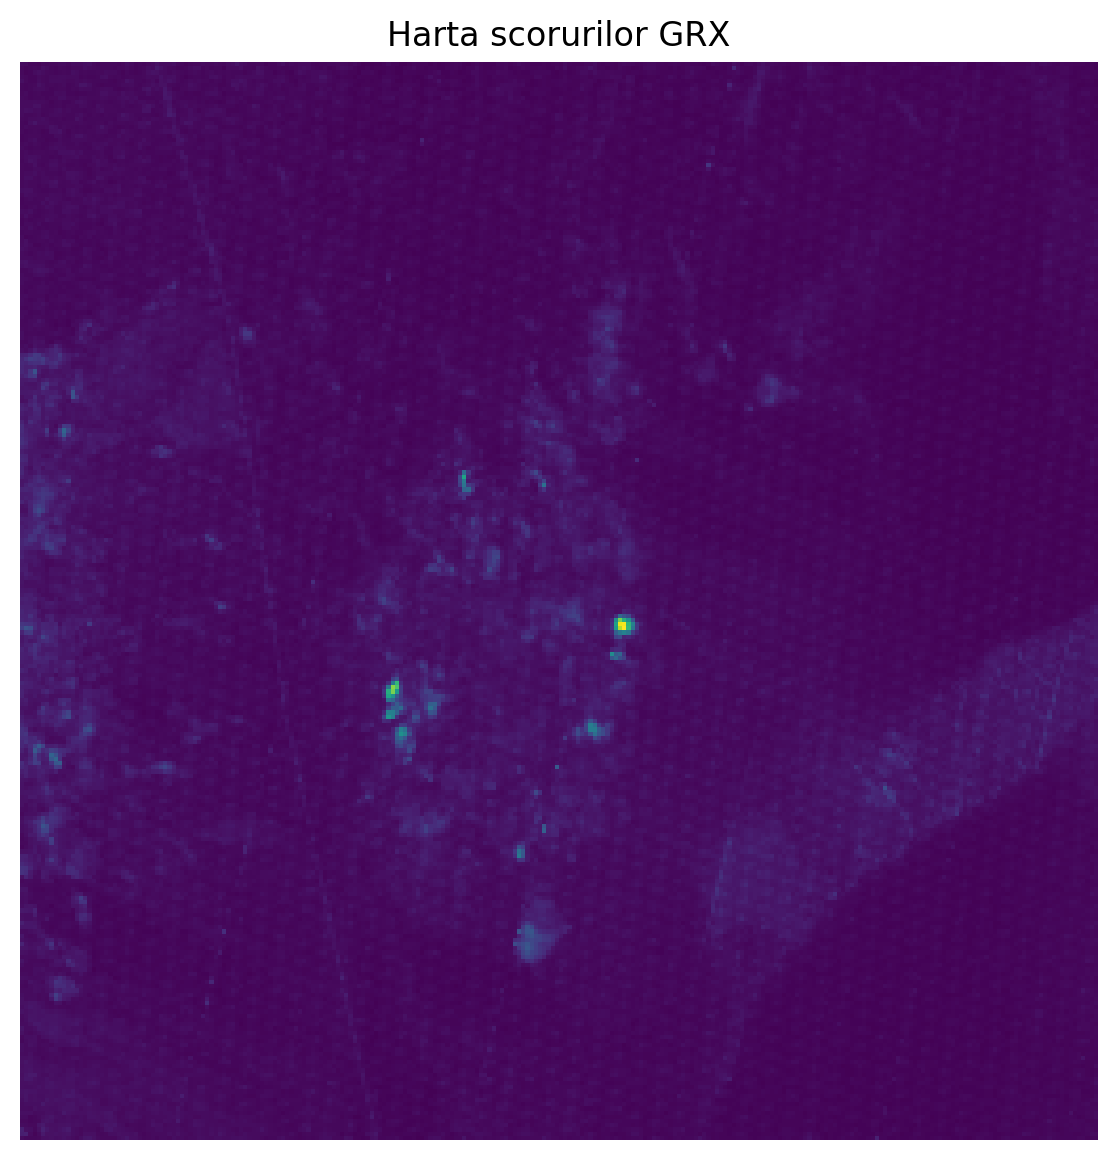

In [10]:
display(Image(filename=str(FIGURE_DIR / "grx_score_map.png")))

## 7. Dataset blind-block și arhitectura DirectNet

Pentru fiecare pixel se extrage un patch `Wout × Wout`. Blocul central `Win × Win` este înlocuit cu pixeli din exteriorul său, astfel încât rețeaua să nu poată copia direct centrul.

Ținta este spectrul original al pixelului central. Dacă rețeaua îl reconstruiește bine, scorul este mic. Dacă reconstrucția diferă mult de original, scorul de anomalie este mare.

In [11]:
# =============================================================================
# 6. DATASET BLIND-BLOCK ȘI ARHITECTURA DIRECTNET
# =============================================================================

class BlindBlockPatchDataset(Dataset):
    def __init__(self, hsi_hwc, wout, win, deterministic=False, seed=42):
        if hsi_hwc.ndim != 3:
            raise ValueError("HSI trebuie să aibă forma H x W x B.")
        if wout % 2 != 1 or win % 2 != 1:
            raise ValueError("Wout și Win trebuie să fie impare.")
        if win > wout:
            raise ValueError("Win nu poate fi mai mare decât Wout.")

        self.hsi = torch.from_numpy(hsi_hwc).float()
        self.h, self.w, self.b = hsi_hwc.shape
        self.wout = int(wout)
        self.win = int(win)
        self.pad = self.wout // 2
        self.center = self.wout // 2
        self.deterministic = bool(deterministic)
        self.seed = int(seed)

        chw = self.hsi.permute(2, 0, 1).unsqueeze(0)
        self.padded = F.pad(
            chw, (self.pad, self.pad, self.pad, self.pad), mode="reflect"
        ).squeeze(0)

        inner_half = self.win // 2
        inner_coords, outer_coords = [], []
        for row in range(self.wout):
            for col in range(self.wout):
                in_inner = (
                    abs(row - self.center) <= inner_half
                    and abs(col - self.center) <= inner_half
                )
                (inner_coords if in_inner else outer_coords).append((row, col))

        self.inner_coords = torch.tensor(inner_coords, dtype=torch.long)
        self.outer_coords = torch.tensor(outer_coords, dtype=torch.long)

    def __len__(self):
        return self.h * self.w

    def __getitem__(self, index):
        row = index // self.w
        col = index % self.w
        patch = self.padded[
            :, row:row + self.wout, col:col + self.wout
        ].clone()
        target = self.hsi[row, col].clone()

        generator = None
        if self.deterministic:
            generator = torch.Generator()
            generator.manual_seed(self.seed + int(index))

        selected_ids = torch.randint(
            0,
            len(self.outer_coords),
            (len(self.inner_coords),),
            generator=generator,
        )
        source_coords = self.outer_coords[selected_ids]
        patch[
            :, self.inner_coords[:, 0], self.inner_coords[:, 1]
        ] = patch[:, source_coords[:, 0], source_coords[:, 1]]
        return patch, target, int(index)


class ResidualBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        x = F.relu(self.bn1(self.conv1(x)), inplace=True)
        x = self.bn2(self.conv2(x))
        return x + residual


class DirectNet(nn.Module):
    def __init__(self, bands, wout, hidden_channels=64):
        super().__init__()
        if (wout - 7) % 4 != 0:
            raise ValueError("Wout trebuie să satisfacă Wout = 4*Nr + 7.")
        self.center = wout // 2
        self.n_res_blocks = (wout - 7) // 4
        self.conv_in = nn.Conv2d(bands, hidden_channels, 3, padding=1)
        self.blocks = nn.Sequential(
            *[ResidualBlock(hidden_channels) for _ in range(self.n_res_blocks)]
        )
        self.conv_penultimate = nn.Conv2d(hidden_channels, hidden_channels, 3, padding=1)
        self.bn_penultimate = nn.BatchNorm2d(hidden_channels)
        self.conv_out = nn.Conv2d(hidden_channels, bands, 3, padding=1)

    def forward(self, x):
        low_level = F.relu(self.conv_in(x), inplace=True)
        high_level = self.blocks(low_level)
        high_level = self.bn_penultimate(self.conv_penultimate(high_level))
        reconstructed_patch = self.conv_out(low_level + high_level)
        return reconstructed_patch[:, :, self.center, self.center]

## 8. Antrenarea unei configurații

Modelul este antrenat self-supervised cu loss L1. O parte dintre pixeli este rezervată pentru urmărirea erorii de validare și pentru early stopping. Această separare nu folosește ground truth; sunt doar patch-uri extrase din aceeași scenă.

In [12]:
# =============================================================================
# 7. TRAIN / VALIDATION ȘI ANTRENARE
# =============================================================================

all_indices = np.arange(H * W)
split_rng = np.random.default_rng(SEED)
split_rng.shuffle(all_indices)
n_validation = min(VALIDATION_SAMPLES, max(1, int(0.1 * len(all_indices))))
validation_indices = all_indices[:n_validation]
training_indices = all_indices[n_validation:]

print("Train:", len(training_indices))
print("Validation:", len(validation_indices))


def train_and_evaluate_config(wout, win, seed=SEED, verbose=True):
    if win > wout:
        raise ValueError("Win trebuie să fie <= Wout.")
    if (wout - 7) % 4 != 0:
        raise ValueError("Wout trebuie să fie de forma 4*Nr+7.")

    set_seed(seed)
    config_name = f"wout{wout}_win{win}"
    checkpoint_path = CHECKPOINT_DIR / f"{config_name}.pt"

    train_base = BlindBlockPatchDataset(hsi_z, wout, win, deterministic=False, seed=seed)
    val_base = BlindBlockPatchDataset(hsi_z, wout, win, deterministic=True, seed=seed + 10000)
    train_subset = Subset(train_base, training_indices.tolist())
    val_subset = Subset(val_base, validation_indices.tolist())

    sampler_generator = torch.Generator().manual_seed(seed)
    sampler = RandomSampler(
        train_subset,
        replacement=True,
        num_samples=TRAIN_SAMPLES_PER_EPOCH,
        generator=sampler_generator,
    )

    train_batch_size = max(4, min(
        BATCH_SIZE, int(3_700_000 / max(1, B * wout * wout))
    ))
    inference_batch_size = max(8, min(
        INFERENCE_BATCH_SIZE, int(7_500_000 / max(1, B * wout * wout))
    ))
    print(
        f"{config_name} | batch train={train_batch_size} | "
        f"batch inference={inference_batch_size}"
    )

    train_loader = DataLoader(
        train_subset,
        batch_size=train_batch_size,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
    )
    val_loader = DataLoader(
        val_subset,
        batch_size=inference_batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
    )

    model = DirectNet(B, wout, HIDDEN_CHANNELS).to(DEVICE)
    criterion = nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6
    )

    best_state = None
    best_val = float("inf")
    wait = 0
    train_history, val_history = [], []
    start = time.perf_counter()

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        train_sum, train_count = 0.0, 0
        for patches, targets, _ in train_loader:
            patches = patches.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            predictions = model(patches)
            loss = criterion(predictions, targets)
            loss.backward()
            optimizer.step()
            train_sum += loss.item() * patches.shape[0]
            train_count += patches.shape[0]
        train_loss = train_sum / train_count

        model.eval()
        val_sum, val_count = 0.0, 0
        with torch.no_grad():
            for patches, targets, _ in val_loader:
                patches = patches.to(DEVICE, non_blocking=True)
                targets = targets.to(DEVICE, non_blocking=True)
                loss = criterion(model(patches), targets)
                val_sum += loss.item() * patches.shape[0]
                val_count += patches.shape[0]
        val_loss = val_sum / val_count
        scheduler.step(val_loss)
        train_history.append(train_loss)
        val_history.append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if verbose:
            print(
                f"{config_name} | epoch {epoch:03d}/{MAX_EPOCHS} | "
                f"train={train_loss:.6f} | val={val_loss:.6f} | "
                f"wait={wait}/{PATIENCE}"
            )
        if wait >= PATIENCE:
            print("Early stopping.")
            break

    training_time = time.perf_counter() - start
    if best_state is None:
        raise RuntimeError(f"Nu s-a salvat un model valid pentru {config_name}.")

    model.load_state_dict(best_state)
    torch.save(
        {
            "model_state_dict": best_state,
            "wout": wout,
            "win": win,
            "bands": B,
            "best_val_loss": best_val,
            "train_history": train_history,
            "val_history": val_history,
            "band_mean": band_mean,
            "band_std": band_std,
        },
        checkpoint_path,
    )

    eval_dataset = BlindBlockPatchDataset(
        hsi_z, wout, win, deterministic=True, seed=seed + 20000
    )
    eval_loader = DataLoader(
        eval_dataset,
        batch_size=inference_batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
    )

    reconstructed = np.zeros((H * W, B), dtype=np.float32)
    model.eval()
    inference_start = time.perf_counter()
    with torch.no_grad():
        for patches, _, indices in eval_loader:
            predictions = model(patches.to(DEVICE, non_blocking=True)).cpu().numpy()
            reconstructed[indices.numpy()] = predictions
    inference_time = time.perf_counter() - inference_start

    scores = np.linalg.norm(hsi_z.reshape(-1, B) - reconstructed, axis=1)
    evaluation = evaluate_scores(scores)

    row = {
        "config": config_name,
        "wout": int(wout),
        "win": int(win),
        "n_res_blocks": int((wout - 7) // 4),
        "epochs_ran": len(train_history),
        "best_val_loss": float(best_val),
        "median_score": evaluation["median_score"],
        "p95_score": evaluation["p95_score"],
        "p99_score": evaluation["p99_score"],
        "p99_5_score": evaluation["p99_5_score"],
        "max_score": evaluation["max_score"],
        "tail_contrast": evaluation["tail_contrast"],
        "threshold": evaluation["threshold"],
        "threshold_method": evaluation["threshold_method"],
        "flagged_pixels": evaluation["flagged_pixels"],
        "flagged_percent": evaluation["flagged_percent"],
        "training_time_s": float(training_time),
        "inference_time_s": float(inference_time),
        "checkpoint": str(checkpoint_path),
    }

    artifacts = {
        "scores": scores,
        "score_map": scores.reshape(H, W),
        "prediction": evaluation["prediction"],
        "prediction_map": evaluation["prediction"].reshape(H, W),
        "train_history": np.asarray(train_history),
        "val_history": np.asarray(val_history),
        "reconstructed": reconstructed,
    }

    del model, train_base, val_base, eval_dataset
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return row, artifacts

Train: 63036
Validation: 2500


## 9. Experimentul cu fereastra interioară `Win`

`Win` controlează cât de mare este zona ascunsă. O zonă prea mică poate lăsa prea multă informație despre obiectul central, iar una prea mare poate elimina context util.

Fără ground truth, configurațiile sunt comparate prin `tail_contrast`: cât de pronunțată este coada scorurilor mari față de distribuția centrală.

In [ ]:
# =============================================================================
# 8. SWEEP WIN
# =============================================================================

win_results = []
win_artifacts = {}

for win in WIN_VALUES:
    print("\n" + "=" * 80)
    row, artifacts = train_and_evaluate_config(REFERENCE_WOUT, win)
    win_results.append(row)
    win_artifacts[row["config"]] = artifacts

win_df = pd.DataFrame(win_results).sort_values("win").reset_index(drop=True)
print(win_df.to_string(index=False))
win_df.to_csv(OUTPUT_DIR / "win_sweep_results.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(win_df["win"], win_df["tail_contrast"], marker="o")
plt.xlabel("Win")
plt.ylabel("Contrast robust al cozii superioare")
plt.title("Separarea nesupravegheată a scorurilor în funcție de Win")
plt.grid(alpha=0.3)
plt.savefig(FIGURE_DIR / "win_vs_tail_contrast.png", dpi=200, bbox_inches="tight")
plt.close()

plt.figure(figsize=(8, 5))
plt.plot(win_df["win"], win_df["best_val_loss"], marker="o")
plt.xlabel("Win")
plt.ylabel("Best validation L1 loss")
plt.title("Eroarea de validare în funcție de Win")
plt.grid(alpha=0.3)
plt.savefig(FIGURE_DIR / "win_vs_validation_loss.png", dpi=200, bbox_inches="tight")
plt.close()


wout19_win1 | batch train=46 | batch inference=94
wout19_win1 | epoch 001/80 | train=0.248323 | val=0.146040 | wait=0/12
wout19_win1 | epoch 002/80 | train=0.134830 | val=0.112695 | wait=0/12
wout19_win1 | epoch 003/80 | train=0.108147 | val=0.100304 | wait=0/12
wout19_win1 | epoch 004/80 | train=0.096714 | val=0.090497 | wait=0/12
wout19_win1 | epoch 005/80 | train=0.090195 | val=0.086678 | wait=0/12
wout19_win1 | epoch 006/80 | train=0.084667 | val=0.080075 | wait=0/12
wout19_win1 | epoch 007/80 | train=0.081070 | val=0.078850 | wait=0/12
wout19_win1 | epoch 008/80 | train=0.076926 | val=0.074537 | wait=0/12
wout19_win1 | epoch 009/80 | train=0.077016 | val=0.075179 | wait=1/12
wout19_win1 | epoch 010/80 | train=0.074284 | val=0.073355 | wait=0/12
wout19_win1 | epoch 011/80 | train=0.074503 | val=0.073728 | wait=1/12
wout19_win1 | epoch 012/80 | train=0.072048 | val=0.067716 | wait=0/12
wout19_win1 | epoch 013/80 | train=0.071644 | val=0.072384 | wait=1/12
wout19_win1 | epoch 014/80

In [ ]:
display(Image(filename=str(FIGURE_DIR / "win_vs_tail_contrast.png")))

## 10. Experimentul cu fereastra exterioară `Wout`

`Wout` controlează dimensiunea contextului folosit pentru predicție. Un context mai mare poate ajuta reconstrucția, dar crește timpul și memoria necesare.

In [ ]:
# =============================================================================
# 9. SWEEP WOUT
# =============================================================================

best_win_row = win_df.loc[win_df["tail_contrast"].idxmax()]
BEST_WIN = int(best_win_row["win"])
print("Cel mai bun Win după contrastul robust al cozii scorurilor:", BEST_WIN)

wout_results = []
wout_artifacts = {}

for wout in WOUT_VALUES:
    config_name = f"wout{wout}_win{BEST_WIN}"
    if config_name in win_artifacts:
        existing = win_df[win_df["config"] == config_name].iloc[0].to_dict()
        wout_results.append(existing)
        wout_artifacts[config_name] = win_artifacts[config_name]
        print("Refolosesc:", config_name)
    else:
        print("\n" + "=" * 80)
        row, artifacts = train_and_evaluate_config(wout, BEST_WIN)
        wout_results.append(row)
        wout_artifacts[row["config"]] = artifacts

wout_df = pd.DataFrame(wout_results).sort_values("wout").reset_index(drop=True)
print(wout_df.to_string(index=False))
wout_df.to_csv(OUTPUT_DIR / "wout_sweep_results.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(wout_df["wout"], wout_df["tail_contrast"], marker="o")
plt.xlabel("Wout")
plt.ylabel("Contrast robust al cozii superioare")
plt.title("Separarea nesupravegheată a scorurilor în funcție de Wout")
plt.grid(alpha=0.3)
plt.savefig(FIGURE_DIR / "wout_vs_tail_contrast.png", dpi=200, bbox_inches="tight")
plt.close()

plt.figure(figsize=(8, 5))
plt.plot(wout_df["wout"], wout_df["inference_time_s"], marker="o")
plt.xlabel("Wout")
plt.ylabel("Timp inferență (s)")
plt.title("Costul de inferență în funcție de Wout")
plt.grid(alpha=0.3)
plt.savefig(FIGURE_DIR / "wout_vs_inference_time.png", dpi=200, bbox_inches="tight")
plt.close()

In [ ]:
display(Image(filename=str(FIGURE_DIR / "wout_vs_tail_contrast.png")))

## 11. Alegerea configurației finale

În absența ground truth-ului, modelul final este configurația cu cel mai mare contrast robust al cozii superioare a scorurilor. Aceasta este o regulă nesupravegheată și nu garantează că toate punctele selectate sunt obiecte de interes.

In [ ]:
# =============================================================================
# 10. CONFIGURAȚIA FINALĂ
# =============================================================================

all_results_df = (
    pd.concat([win_df, wout_df], ignore_index=True)
    .drop_duplicates("config")
    .reset_index(drop=True)
)

best_row = all_results_df.loc[all_results_df["tail_contrast"].idxmax()]
BEST_CONFIG = str(best_row["config"])
all_results_df.to_csv(OUTPUT_DIR / "all_experiment_results.csv", index=False)

all_artifacts = {**win_artifacts, **wout_artifacts}
best_artifacts = all_artifacts[BEST_CONFIG]
best_scores = best_artifacts["scores"]
best_score_map = best_artifacts["score_map"]
best_prediction = best_artifacts["prediction"]
best_prediction_map = best_artifacts["prediction_map"]

np.save(OUTPUT_DIR / "best_scores.npy", best_scores)
np.save(OUTPUT_DIR / "best_score_map.npy", best_score_map)
np.save(OUTPUT_DIR / "best_prediction_map.npy", best_prediction_map)
np.save(
    OUTPUT_DIR / "best_reconstructed_spectra.npy",
    best_artifacts["reconstructed"],
)

print("Configurația finală după contrastul robust al cozii scorurilor:", BEST_CONFIG)
print(best_row)

plt.figure(figsize=(8, 5))
plt.plot(best_artifacts["train_history"], label="Train")
plt.plot(best_artifacts["val_history"], label="Validation")
plt.xlabel("Epocă")
plt.ylabel("L1 loss")
plt.title(f"Curbele de antrenare — {BEST_CONFIG}")
plt.grid(alpha=0.3)
plt.legend()
plt.savefig(FIGURE_DIR / "best_training_curves.png", dpi=200, bbox_inches="tight")
plt.close()

In [ ]:
display(Image(filename=str(FIGURE_DIR / "best_training_curves.png")))

## 12. Comparația GRX–DirectNet

Scorurile celor două metode au scări diferite. Pentru comparația distribuțiilor, fiecare set este împărțit la propria mediană.

In [ ]:
# =============================================================================
# 11. COMPARAȚIA GRX VS DIRECTNET
# =============================================================================

# Scările GRX și DirectNet sunt diferite, deci le normalizăm la mediană.
grx_normalized = grx_scores_flat / (np.median(grx_scores_flat) + 1e-12)
best_normalized = best_scores / (np.median(best_scores) + 1e-12)
upper = max(
    np.percentile(grx_normalized, 99.5),
    np.percentile(best_normalized, 99.5),
)

plt.figure(figsize=(8, 6))
plt.hist(
    grx_normalized,
    bins=100,
    range=(0, upper),
    density=True,
    alpha=0.5,
    label="GRX / mediană",
)
plt.hist(
    best_normalized,
    bins=100,
    range=(0, upper),
    density=True,
    alpha=0.5,
    label=f"{BEST_CONFIG} / mediană",
)
plt.xlabel("Scor normalizat")
plt.ylabel("Densitate")
plt.title("Distribuția scorurilor fără ground truth")
plt.grid(alpha=0.3)
plt.legend()
plt.savefig(
    FIGURE_DIR / "final_score_distribution_comparison.png",
    dpi=200,
    bbox_inches="tight",
)
plt.close()

In [ ]:
display(Image(filename=str(FIGURE_DIR / "final_score_distribution_comparison.png")))

## 13. Harta finală a scorurilor

Harta continuă arată intensitatea scorului de anomalie. Harta binară aplică pragul percentilei implicite. Pixelii albi sunt candidați care trebuie interpretați sau verificați separat.

In [ ]:
# =============================================================================
# 12. HĂRȚILE FINALE ȘI DISTRIBUȚIA SCORURILOR
# =============================================================================

score_display = (
    best_score_map - best_score_map.min()
) / (best_score_map.max() - best_score_map.min() + 1e-12)

plt.figure(figsize=(7, 7))
plt.imshow(score_display)
plt.title(f"Harta de anomalii — {BEST_CONFIG}")
plt.axis("off")
plt.savefig(FIGURE_DIR / "best_anomaly_map.png", dpi=200, bbox_inches="tight")
plt.close()

plt.figure(figsize=(7, 7))
plt.imshow(best_prediction_map)
plt.title(f"Candidați binari — {best_row['threshold_method']}")
plt.axis("off")
plt.savefig(FIGURE_DIR / "best_binary_prediction.png", dpi=200, bbox_inches="tight")
plt.close()

threshold = float(best_row["threshold"])
upper = np.percentile(best_scores, 99.9)
plt.figure(figsize=(8, 5))
plt.hist(best_scores, bins=120, range=(0, upper))
plt.axvline(threshold, linestyle="--", label=f"Prag={threshold:.4f}")
plt.xlabel("Scor de anomalie")
plt.ylabel("Număr pixeli")
plt.title(f"Distribuția scorurilor — {BEST_CONFIG}")
plt.grid(alpha=0.3)
plt.legend()
plt.savefig(FIGURE_DIR / "best_score_histogram.png", dpi=200, bbox_inches="tight")
plt.close()

In [ ]:
display(Image(filename=str(FIGURE_DIR / "best_anomaly_map.png")))
display(Image(filename=str(FIGURE_DIR / "best_binary_prediction.png")))

## 14. Influența pragului

Un prag mai permisiv selectează mai mulți candidați. Un prag mai strict păstrează numai scorurile extreme. Fără ground truth nu există o percentilă universal corectă; alegerea depinde de câte zone poate verifica utilizatorul.

In [ ]:
# =============================================================================
# 13. ANALIZA PRAGURILOR
# =============================================================================

percentiles_to_test = [95, 97, 98, 99, 99.25, 99.5, 99.7, 99.8, 99.9]
threshold_rows = []

for percentile in percentiles_to_test:
    current_threshold = float(np.percentile(best_scores, percentile))
    prediction = (best_scores >= current_threshold).astype(np.uint8)
    selected_scores = best_scores[prediction == 1]
    threshold_rows.append({
        "percentile": percentile,
        "threshold": current_threshold,
        "flagged_pixels": int(prediction.sum()),
        "flagged_percent": float(100 * prediction.mean()),
        "mean_selected_score": float(selected_scores.mean()),
        "median_selected_score": float(np.median(selected_scores)),
    })

threshold_df = pd.DataFrame(threshold_rows)
print(threshold_df.to_string(index=False))
threshold_df.to_csv(OUTPUT_DIR / "threshold_analysis.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["percentile"], threshold_df["threshold"], marker="o")
plt.xlabel("Percentila pragului")
plt.ylabel("Valoarea threshold-ului")
plt.title("Threshold-ul scorului în funcție de percentilă")
plt.grid(alpha=0.3)
plt.savefig(
    FIGURE_DIR / "threshold_value_by_percentile.png",
    dpi=200,
    bbox_inches="tight",
)
plt.close()

for percentile in [99, 99.5, 99.9]:
    current_threshold = np.percentile(best_scores, percentile)
    prediction_map = (best_scores >= current_threshold).reshape(H, W)
    plt.figure(figsize=(7, 7))
    plt.imshow(prediction_map)
    plt.title(f"Candidați la percentila {percentile}")
    plt.axis("off")
    safe_name = str(percentile).replace(".", "_")
    plt.savefig(
        FIGURE_DIR / f"prediction_percentile_{safe_name}.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.close()

In [ ]:
display(Image(filename=str(FIGURE_DIR / "threshold_value_by_percentile.png")))

## 15. Cele mai puternice anomalii candidate

Sunt extrase primele șase poziții după scor. Crucea indică pixelul analizat. Panoul conține pseudocolorul local, scorul local și predicția binară.

In [ ]:
# =============================================================================
# 14. CELE MAI PUTERNICE ANOMALII CANDIDATE
# =============================================================================


def normalize_grayscale(array):
    array = np.asarray(array, dtype=np.float32)
    lo, hi = float(array.min()), float(array.max())
    return np.zeros_like(array) if hi <= lo else (array - lo) / (hi - lo)


def crop_bounds(row, col, radius):
    return (
        max(0, row - radius),
        min(H, row + radius + 1),
        max(0, col - radius),
        min(W, col + radius + 1),
    )


def mark_pixel_with_cross(image, row, col):
    output = image.copy()
    r0, r1 = max(0, row - 2), min(output.shape[0], row + 3)
    c0, c1 = max(0, col - 2), min(output.shape[1], col + 3)
    output[row, c0:c1] = 1.0
    output[r0:r1, col] = 1.0
    return output


def build_candidate_panel(flat_index, case_name, crop_radius=10):
    row, col = int(flat_index // W), int(flat_index % W)
    r0, r1, c0, c1 = crop_bounds(row, col, crop_radius)
    local_row, local_col = row - r0, col - c0

    pca_crop = mark_pixel_with_cross(
        pca_rgb[r0:r1, c0:c1], local_row, local_col
    )
    score_crop = normalize_grayscale(best_score_map[r0:r1, c0:c1])
    score_rgb = np.repeat(score_crop[..., None], 3, axis=2)
    score_rgb = mark_pixel_with_cross(score_rgb, local_row, local_col)
    pred_rgb = np.repeat(
        best_prediction_map[r0:r1, c0:c1, None].astype(np.float32),
        3,
        axis=2,
    )
    separator = np.ones((pca_crop.shape[0], 2, 3), dtype=np.float32)
    panel = np.concatenate(
        [pca_crop, separator, score_rgb, separator, pred_rgb],
        axis=1,
    )
    title = (
        f"{case_name} | coord=({row}, {col}) | "
        f"score={best_scores[flat_index]:.4f} | "
        f"selectat={int(best_prediction[flat_index])}\n"
        "Pseudocolor | Scor local | Hartă binară"
    )
    return panel, title


top_indices = np.argsort(best_scores)[::-1][:6]
candidate_rows = []
for number, flat_index in enumerate(top_indices, start=1):
    row, col = divmod(int(flat_index), W)
    candidate_rows.append({
        "rank": number,
        "flat_index": int(flat_index),
        "row": row,
        "col": col,
        "score": float(best_scores[flat_index]),
        "selected_at_default_threshold": int(best_prediction[flat_index]),
    })
    panel, title = build_candidate_panel(
        int(flat_index), f"Anomalie candidată {number}"
    )
    plt.figure(figsize=(11, 4))
    plt.imshow(panel)
    plt.title(title)
    plt.axis("off")
    plt.savefig(
        FIGURE_DIR / f"top_anomaly_candidate_{number}.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.close()

pd.DataFrame(candidate_rows).to_csv(
    OUTPUT_DIR / "top_anomaly_candidates.csv",
    index=False,
)

In [ ]:
for index in range(1, 4):
    display(Image(filename=str(FIGURE_DIR / f"top_anomaly_candidate_{index}.png")))

## 16. Tabelul final și arhiva rezultatelor

La final sunt salvate CSV-uri, hărți `.npy`, checkpoint-uri PyTorch, grafice și o arhivă ZIP. Rezultatele trebuie interpretate ca detecții nesupravegheate; fără ground truth nu pot fi confirmate automat.

In [ ]:
# =============================================================================
# 15. TABEL FINAL ȘI ARHIVĂ ZIP
# =============================================================================

grx_row = {
    "config": "GRX",
    "wout": np.nan,
    "win": np.nan,
    "n_res_blocks": 0,
    "epochs_ran": 0,
    "best_val_loss": np.nan,
    "median_score": grx_eval["median_score"],
    "p95_score": grx_eval["p95_score"],
    "p99_score": grx_eval["p99_score"],
    "p99_5_score": grx_eval["p99_5_score"],
    "max_score": grx_eval["max_score"],
    "tail_contrast": grx_eval["tail_contrast"],
    "threshold": grx_eval["threshold"],
    "threshold_method": grx_eval["threshold_method"],
    "flagged_pixels": grx_eval["flagged_pixels"],
    "flagged_percent": grx_eval["flagged_percent"],
    "training_time_s": 0.0,
    "inference_time_s": grx_time,
    "checkpoint": "-",
}

presentation_table = pd.concat(
    [pd.DataFrame([grx_row]), all_results_df],
    ignore_index=True,
)
presentation_columns = [
    "config",
    "wout",
    "win",
    "best_val_loss",
    "tail_contrast",
    "median_score",
    "p99_5_score",
    "threshold",
    "threshold_method",
    "flagged_pixels",
    "flagged_percent",
    "training_time_s",
    "inference_time_s",
]
presentation_table = (
    presentation_table[presentation_columns]
    .sort_values("tail_contrast", ascending=False)
    .reset_index(drop=True)
)
print(presentation_table.to_string(index=False))
presentation_table.to_csv(
    OUTPUT_DIR / "presentation_results_table.csv",
    index=False,
)

run_info = {
    "dataset": DATASET_NAME,
    "data_path": str(DATA_PATH),
    "source_files": source_metadata["source_files"],
    "cube_key": cube_key,
    "original_cube_shape": source_original_shape,
    "final_hsi_shape": str(tuple(hsi_z.shape)),
    "orientation": orientation_info,
    "roi": source_metadata["roi"],
    "has_ground_truth": False,
    "best_config": BEST_CONFIG,
    "selection_metric": "tail_contrast",
    "default_threshold_percentile": DEFAULT_THRESHOLD_PERCENTILE,
}
pd.DataFrame([run_info]).to_csv(OUTPUT_DIR / "run_info.csv", index=False)

archive_base = SCRIPT_DIR / f"directnet_experiments_{DATASET_NAME}"
archive_path = shutil.make_archive(
    str(archive_base),
    "zip",
    root_dir=OUTPUT_DIR,
)

print("Arhivă creată:", archive_path)
print("Rezultatele sunt salvate în:", OUTPUT_DIR)
print(
    "IMPORTANT: pixelii marcați sunt candidați de anomalie, nu obiecte "
    "confirmate. Fără ground truth nu pot fi calculate ROC-AUC, Precision, "
    "Recall, FP sau FN."
)

## Observație finală

DirectNet nu spune „acesta este un tanc”, „aceasta este o mașină” sau „aceasta este o clădire”. El spune doar că un pixel sau o regiune este dificil de prezis din contextul local și are un spectru neobișnuit. Identificarea semantică necesită analiză umană, date auxiliare sau un model antrenat pentru clase concrete.